In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('custom')

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:

a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)

I_simp = (h/3) * (f[0] + 2*sum(f[:n-2:2]) \
            + 4*sum(f[1:n-1:2]) + f[n-1])
err_simp = 2 - I_simp

print(I_simp)
print(err_simp)

2.0001095173150043
-0.00010951731500430384


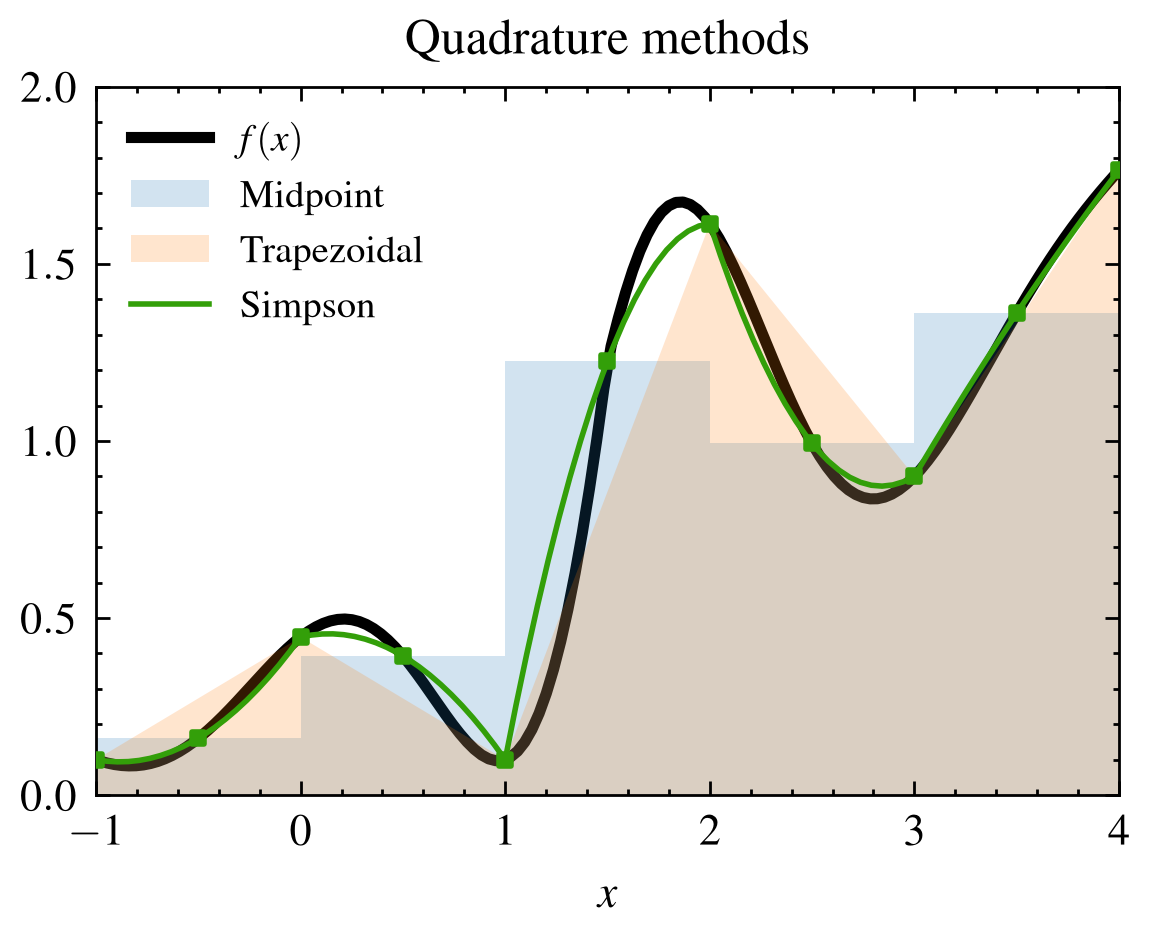

In [4]:
def f(x):
    # Gaussian-like envelope with high-frequency wiggles and a sharp cusp
    return np.exp(-np.abs(x - 1.5)) * (1 + np.cos(np.pi * x)) + 0.1 * x**2

methods = ['Midpoint', 'Trapezoidal', 'Simpson']
colors = ['#1f77b4', '#ff7f0e', "#339F09"]

# Range and Number of Bins
a, b = -2, 5
n_bins = int(b-a)
bin_edges = np.linspace(a, b, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
dx = (b - a) / n_bins

# High-res x for plotting the true function
x_fine = np.linspace(a, b, 200)
y_fine = f(x_fine)

fig, ax = plt.subplots()
ax.plot(x_fine, y_fine, 'k', lw=2, zorder=-1, label=r'$f(x)$')

# --- Midpoint Rule ---
ax.bar(bin_centers, f(bin_centers), width=dx, alpha=0.2, color=colors[0], label='Midpoint')

# --- Trapezoidal Rule ---
ax.fill_between(bin_edges, 0, f(bin_edges),
                alpha=0.2,
                facecolor=colors[1],
                edgecolor='none',
                label='Trapezoidal'
                )

# --- Simpson's Rule ---
# Points for Simpson (edges + centers to visualize the quadratic arcs)
simpson_x = np.linspace(a, b, n_bins * 2 + 1)
simpson_y = f(simpson_x)
ax.scatter(simpson_x, simpson_y, color=colors[2], marker='s', s=5, zorder=5,)

# Visualize quadratic segments
for i in range(n_bins):

    # Segment x: edge_i, center_i, edge_i+1
    seg_x = np.linspace(bin_edges[i], bin_edges[i+1], 20)

    # Quadratic fit through (x0, y0), (x_mid, y_mid), (x1, y1)
    x0, xm, x1 = bin_edges[i], bin_centers[i], bin_edges[i+1]
    y0, ym, y1 = f(x0), f(xm), f(x1)

    # Lagrange polynomial for these 3 points
    poly = (y0 * (seg_x - xm) * (seg_x - x1) / ((x0 - xm) * (x0 - x1)) +
            ym * (seg_x - x0) * (seg_x - x1) / ((xm - x0) * (xm - x1)) +
            y1 * (seg_x - x0) * (seg_x - xm) / ((x1 - x0) * (x1 - xm)))
    ax.plot(seg_x, poly, color=colors[2], lw=1, label='Simpson' if i == 0 else None)


# Fetch all handles and labels
handles, labels = ax.get_legend_handles_labels()

# Define your desired order explicitly
order = [r'$f(x)$', 'Midpoint', 'Trapezoidal', 'Simpson']

# Create a mapping and sort handles
handle_dict = dict(zip(labels, handles))
sorted_handles = [handle_dict[label] for label in order if label in handle_dict]
sorted_labels = [label for label in order if label in handle_dict]

ax.legend(sorted_handles, sorted_labels, loc='upper left', fontsize=7)

ax.set_xlabel(r'$x$')
ax.set_xlim(a+1, b-1)
ax.set_ylim(0, 2)
ax.set_title('Quadrature methods', fontsize=9)

plt.savefig('kernel_quadrature_methods.png', dpi=500, bbox_inches='tight', transparent=False)
plt.show()